# 03 — Label Targets & Temporal Split

Define what "vol crush profitable" means for each event and split the data
in time so we can evaluate honestly on out-of-sample test events.

## Definition (verbatim from the NVDA pilot)

A short straddle is profitable if the actual move is smaller than the move
the market priced in:

```
crush_profitable = abs(actual_move_pct) < straddle_pct_pre
crush_pnl_pct    = straddle_pct_pre - abs(actual_move_pct)
```

Both quantities are in % of stock price. Positive `crush_pnl_pct` means the
stock moved less than the straddle priced — we kept the premium.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

from unified_strategy.label_targets import label_crush, split_summary, temporal_split

df = pd.read_csv("data/02_event_features.csv", parse_dates=["announcement_date"])
print(f"Loaded {len(df):,} labeled events")
df[["ticker", "announcement_date", "straddle_pct_pre", "actual_move_pct",
    "crush_profitable", "crush_pnl_pct"]].head(8)

Loaded 7,886 labeled events


,ticker,announcement_date,straddle_pct_pre,actual_move_pct,crush_profitable,crush_pnl_pct
0,ACN,2021-06-24,2.508772,3.508772,0,-1.000000
1,CCL,2021-06-28,4.035714,7.142857,0,-3.107143
2,FDS,2021-06-29,5.470588,0.000000,1,5.470588
3,MU,2021-06-30,5.385542,3.614458,1,1.771084
4,STZ,2021-06-30,4.322581,0.000000,1,4.322581
5,MKC,2021-07-01,4.638889,0.000000,1,4.638889
6,PEP,2021-07-13,1.930000,3.333333,0,-1.403333
7,JPM,2021-07-13,2.765079,1.587302,1,1.177778


## 1. Crush rate at the population level

In [2]:
crush_rate = df["crush_profitable"].mean()
print(f"Pooled crush rate: {100 * crush_rate:.2f}%")
print(f"This is the always-short baseline win rate.")
print()
print("Per-trade P&L distribution (% of stock price):")
print(df["crush_pnl_pct"].describe().round(3).to_string())

Pooled crush rate: 66.51%
This is the always-short baseline win rate.

Per-trade P&L distribution (% of stock price):
count    7886.000
mean        1.233
std         4.523
min       -34.821
25%        -1.066
50%         1.682
75%         4.185
max        17.667


## 2. Asymmetry: wins are small, losses are big

This is the central risk of vol selling. The histogram below is **left-skewed**:
many small profitable trades, a fat negative tail of disasters.

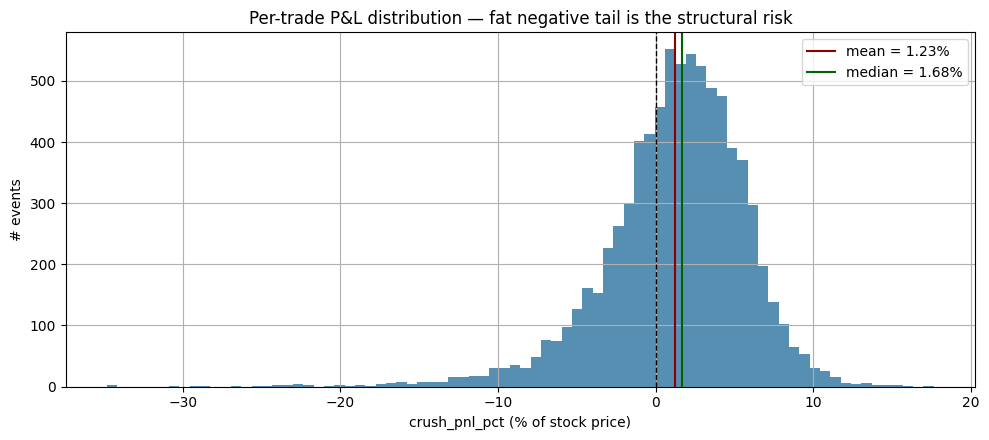


Worst 5 events (biggest realized moves vs straddle):
ticker announcement_date  straddle_pct_pre  actual_move_pct  crush_pnl_pct
  DXCM        2024-07-25          8.035714        42.857143     -34.821429
   APP        2024-11-06         14.000000        48.484848     -34.484848
  SNPS        2025-09-09          5.672131        36.065574     -30.393443
   TTD        2021-11-08         14.705882        44.117647     -29.411765
  ORCL        2025-09-09          9.305263        37.894737     -28.589474


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
df["crush_pnl_pct"].hist(bins=80, ax=ax, color="#3a7ca5", alpha=0.85)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(df["crush_pnl_pct"].mean(), color="darkred", linewidth=1.5,
           label=f"mean = {df['crush_pnl_pct'].mean():.2f}%")
ax.axvline(df["crush_pnl_pct"].median(), color="darkgreen", linewidth=1.5,
           label=f"median = {df['crush_pnl_pct'].median():.2f}%")
ax.set_xlabel("crush_pnl_pct (% of stock price)")
ax.set_ylabel("# events")
ax.set_title("Per-trade P&L distribution — fat negative tail is the structural risk")
ax.legend()
plt.tight_layout()
plt.show()

print()
print("Worst 5 events (biggest realized moves vs straddle):")
worst = df.nsmallest(5, "crush_pnl_pct")[
    ["ticker", "announcement_date", "straddle_pct_pre", "actual_move_pct", "crush_pnl_pct"]
]
print(worst.to_string(index=False))

## 3. Temporal train / val / test split

All temporal pipeline. Each event is assigned to:

| Split | Range | Purpose |
|---|---|---|
| train | ≤ 2023-09-30 | Fit models |
| val | 2023-10-01 → 2024-09-30 | Calibrate probabilities, tune threshold |
| test | ≥ 2024-10-01 | Frozen 18-month OOS evaluation |

Boundary respects two prior conventions: pre-2023 train (the user's per-stock
pipeline cutoff) and an 18-month OOS window (Joshua's SPY backtest convention).

In [4]:
print(split_summary(df).to_string(index=False))

split  n_events  pct_total   date_min   date_max  crush_rate
train      3917       49.7 2021-06-24 2023-09-29        68.1
  val      1774       22.5 2023-10-03 2024-09-30        62.2
 test      2195       27.8 2024-10-01 2025-12-02        67.1


## 4. Crush rate stability across splits

If train and test crush rates diverge sharply, we have regime change to deal
with. In our case they're tight (within ~6pp), so the temporal split is sound.

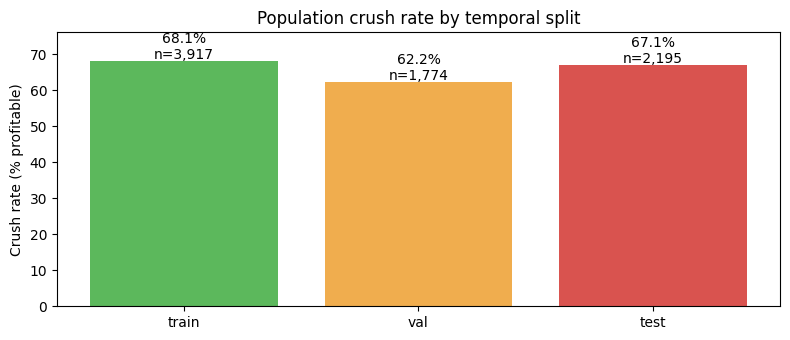

In [5]:
masks = temporal_split(df)
fig, ax = plt.subplots(figsize=(8, 3.5))
splits = ["train", "val", "test"]
rates = [df[masks[s]]["crush_profitable"].mean() * 100 for s in splits]
counts = [masks[s].sum() for s in splits]
bars = ax.bar(splits, rates, color=["#5cb85c", "#f0ad4e", "#d9534f"])
for bar, c, r in zip(bars, counts, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, r + 0.5,
            f"{r:.1f}%\nn={c:,}", ha="center", fontsize=10)
ax.set_ylabel("Crush rate (% profitable)")
ax.set_ylim(0, max(rates) + 8)
ax.set_title("Population crush rate by temporal split")
plt.tight_layout()
plt.show()

## 5. Output

This notebook adds nothing on top of `02_event_features.csv` — the crush
columns were already computed there. Its purpose is documentation: define
the target, surface the loss-asymmetry risk, sanity-check the split.